In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult

In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots
import circle_results_tools as crt

## 1. Define analysis inputs

Edit these values if needed.

In [3]:
# Example placeholders: edit to your current values
name_file = "LVM-30Dor-6563"
catalog_path = "fits_ready/circle_catalog.csv"
filelist_path = "fits_ready/filelist.txt"

# These should already exist in your notebook/session:
# MAPS_DIR
# results_comp
# wcs
# radius = 413 * u.arcsec
# pc = ...

## 2. Load the list of exported circle names

In [4]:
with open(filelist_path, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

names[:5], len(names)

(['LVM-30Dor-6563_A',
  'LVM-30Dor-6563_B1',
  'LVM-30Dor-6563_B2',
  'LVM-30Dor-6563_B3',
  'LVM-30Dor-6563_B5'],
 7)

## 3. Load all bundles

In [5]:
bundles = {}
for name in names:
    bundles[name] = results_comp.load_line_bundle(name, name, MAPS_DIR, read_header=True)

dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

## 4. Load the circle catalog

In [6]:
circles_df, circles = crt.load_circle_catalog(catalog_path, name_file)
circles_df.head()

,label,ring,angle_deg,ra_deg,dec_deg,radius_arcsec,name
0,A,A,NaN,84.675000,-69.100000,826.0,LVM-30Dor-6563_A
1,B1,B,0.000000,84.675000,-68.641111,826.0,LVM-30Dor-6563_B1
2,B2,B,51.428571,85.667646,-68.810986,826.0,LVM-30Dor-6563_B2
3,B3,B,102.857143,85.934800,-69.197516,826.0,LVM-30Dor-6563_B3
4,B5,B,205.714286,84.106131,-69.512520,826.0,LVM-30Dor-6563_B5


## 5. Build the one-row-per-circle summary table

In [7]:
pc = meta_all['LVM-30Dor-6563_A']['PC']
radius_arcsec = circles[0]['radius_arcsec']

results_df = crt.build_circle_results_df(
    circles,
    dfs_fit,
    radius_arcsec=radius_arcsec,
    pc=pc,
    param_row=0,
)

## 6. Sky plot of fitted values inside the circles

In [8]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle

c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

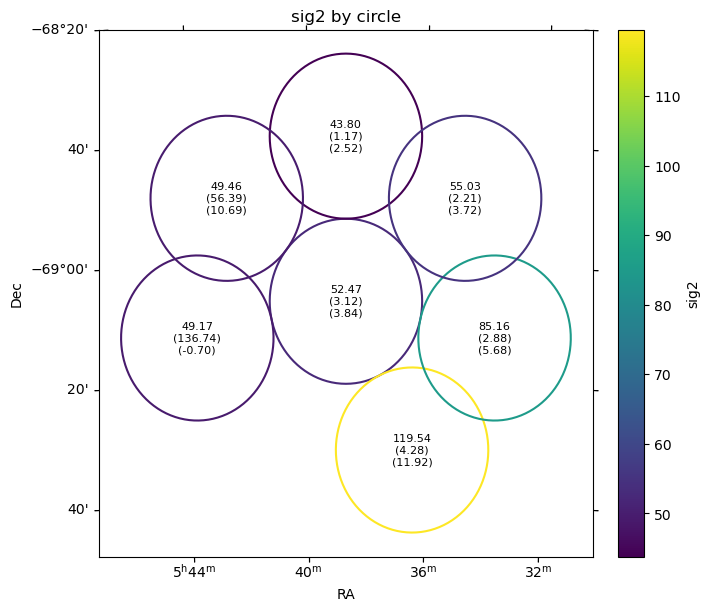

In [9]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="sig2",
    title="sig2 by circle",
    cmap="viridis",
    fontsize=8,
)

Try the same for `r0` and `m`.

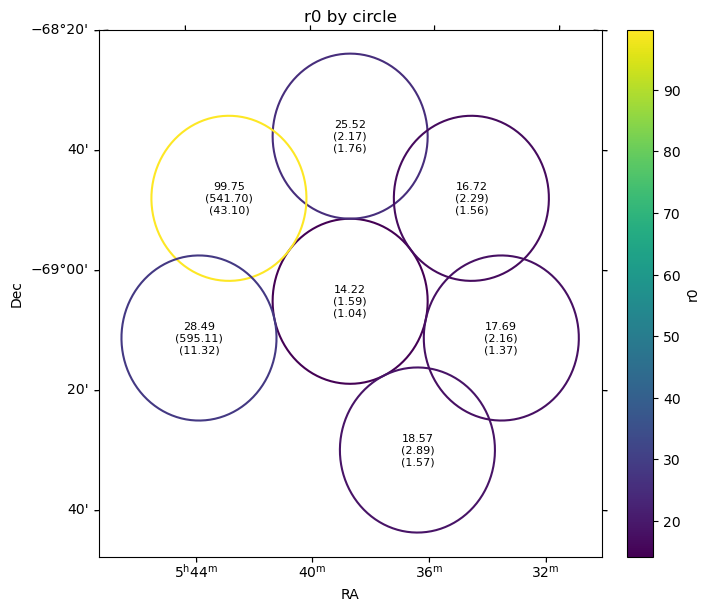

In [10]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="r0",
    title="r0 by circle",
    cmap="viridis",
    fontsize=8,
)

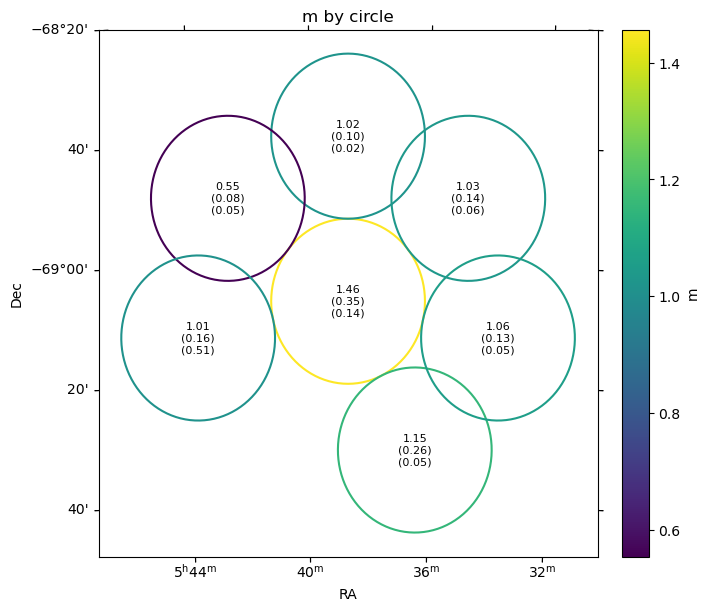

In [11]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="m",
    title="m by circle",
    cmap="viridis",
    fontsize=8,
)

## 7. Ring-level statistics

In [12]:
stats_sig_ring = crt.compute_group_stats(results_df, "sig", group_col="ring", order=["center", "inner", "middle", "outer"])
stats_sig_ring

,ring,count,mean,std,median
0,NaN,1,7.243284,NaN,7.243284
1,NaN,6,8.040485,1.688906,7.225387


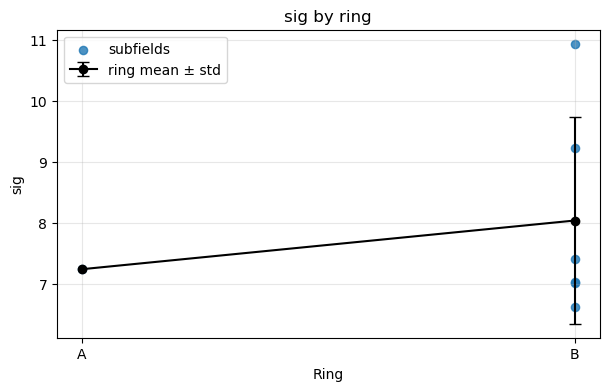

In [13]:
fig, ax, stats_df = crt.plot_parameter_by_ring(
    results_df,
    "sig",
    title="sig by ring",
    ylabel="sig",
)

## 8. Radius-in-pc version

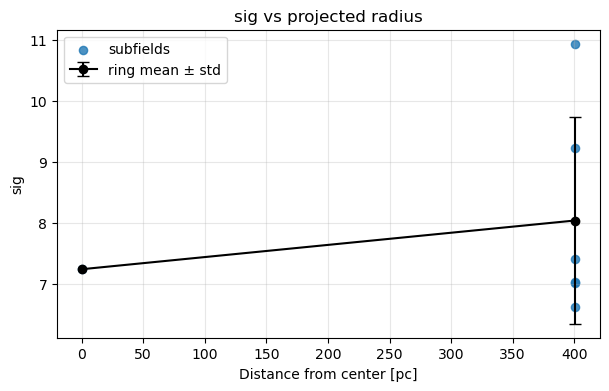

In [14]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "sig",
    title="sig vs projected radius",
    ylabel="sig",
    jitter=0.02,
)

## 9. Repeat for `r0` and `m`

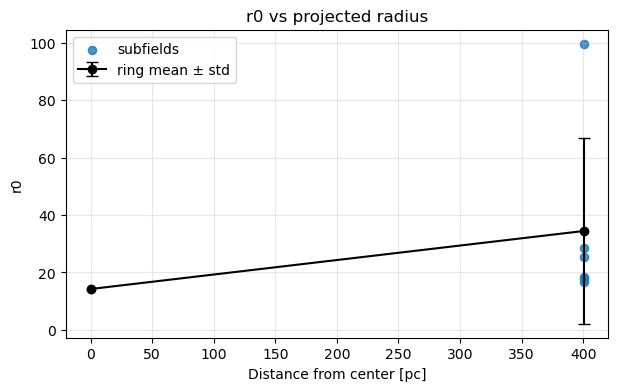

In [15]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "r0",
    title="r0 vs projected radius",
    ylabel="r0",
    jitter=0.02,
)

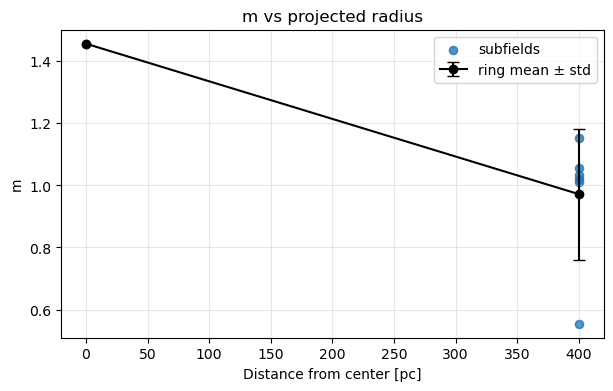

In [16]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "m",
    title="m vs projected radius",
    ylabel="m",
    jitter=0.02,
)